In [1]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam, Adadelta

rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [2]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "dv0_withoutstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [3]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 64 … 77


In [4]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (99996, 82)
Global Participant_ID range: 6 … 77


In [5]:
df_all

,Unnamed: 0,Time,Zone_0,Zone_1,Zone_2,Zone_3,Zone_4,Zone_5,Zone_6,Zone_7,...,Container_Weight,drink,temp,prev,next,sip_start,sip_end,sip_id,dV,TOTAL_SIP_TIME
0,0,1747823631000,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
1,1,1747823631200,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
2,2,1747823631400,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
3,3,1747823631600,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
4,4,1747823631800,2162,2155,3941,362,324,342,3605,2071,...,19.8,coke-r,c,0,0,False,False,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99991,20621,1750719007400,1647,1625,1610,1610,1592,1569,1580,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99992,20622,1750719007600,1637,1611,1592,1596,1570,1569,1575,1569,...,7.7,water,n,0,0,False,False,5,0.0,0
99993,20623,1750719007800,1607,1607,1592,1595,1568,1567,1560,1566,...,7.7,water,n,0,0,False,False,5,0.0,0
99994,20624,1750719008000,1602,1593,1586,1585,1568,1562,1560,1560,...,7.7,water,n,0,0,False,False,5,0.0,0


In [6]:
df = df_all

In [7]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [8]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 1                                   # 1 = ragged, >1 = padded


In [9]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================
df = df[df["Label"] == 1]                        # keep only annotated frames

feature_cols = df.columns[2:66]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:                                # ← drop empty sip
        skip_count += 1
        continue
    X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
    y.append(dV)

y = np.asarray(y, np.float32)
X = np.array(X, dtype=object)   # each element is still a (T,64) array
print(f"Total sips kept : {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", y.min(), "max:", y.max())

Total sips kept : 383
Zero-volume skipped : 2
Label stats  → min: 1.4691479 max: 160.2


In [10]:
X[:1]

array([array([[2487.,  165.,  348., ...,  364.,  330., 1817.],
              [2487.,  165.,  348., ...,  364.,  330., 1817.],
              [ 265.,  200.,  234., ...,  364.,  352., 1817.],
              ...,
              [ 304., 2267., 2300., ...,  331., 1449., 1140.],
              [ 299., 2267., 2300., ...,  352.,  352., 1151.],
              [ 295., 2280., 2300., ...,  352., 1449., 1151.]], dtype=float32)],
      dtype=object)

In [11]:
print(type(X))          # <class 'numpy.ndarray'>
print(X.shape)          # (number,)

print(type(X[0]))       # <class 'numpy.ndarray'>
print(X[0].shape)       # (rows, columns)

<class 'numpy.ndarray'>
(383,)
<class 'numpy.ndarray'>
(26, 64)


In [12]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train = X[idx[:split1]], y[idx[:split1]]
X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)


Train 245 Val 61  Test 77


In [13]:
# X_train


In [14]:
# y_train

In [15]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  



In [16]:
# X_train

In [17]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [18]:
train_ds

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [19]:
# for batch in train_ds.take(1):
#     x_batch, y_batch = batch
#     print("x_batch shape:", x_batch.shape)
#     print("y_batch shape:", y_batch.shape)
#     print("x_batch:", x_batch.numpy())
#     print("y_batch:", y_batch.numpy())

In [20]:
# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=2,
        dilations=[1,2,4,8,16,32],   # ~64-time-step field
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
model = tf.keras.Model(inp, out)

model.compile(
    # tf.keras.optimizers.Adam(1e-3),        # a bit faster
    optimizer=Adagrad(learning_rate=0.01),
    loss="mae"                             # MAE is more robust
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# weights = (y_train / y_train.max()) ** 0.5  
cb = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss', patience=15, restore_best_weights=True)
model.fit(
    train_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,        # ⬅ use VALIDATION set
    validation_steps=val_steps,
    verbose=1,
    # sample_weight=weights,
    callbacks=[cb]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 128)            │       386,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,817 (1.48 MB)

 Trainable params: 386,817 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 20.9642 - val_loss: 28.6906
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 21.1053 - val_loss: 20.1607
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 16.2179 - val_loss: 14.5843
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 14.2591 - val_loss: 15.3366
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 14.0724 - val_loss: 16.0252
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 13.0152 - val_loss: 14.9068
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 11.7181 - val_loss: 14.7955
Epoch 8/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 10.1974 - val_loss: 15.2295
Epoch 9/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 11.8423 - val_loss: 15.2426
Epoch 10/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.6584 - val_loss: 15.0294
Epoch 11/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.9411 - val_loss: 14.2667
Epoch 12/50
245/245 ━━━━━━━━━━━━

In [21]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [22]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 77 test sips
  MSE   : 262.1076
  RMSE  : 16.1897
  R²    : 0.5975
  RMSPE : 116.95%

First 50 predictions:
     Actual dV  Predicted dV
0   103.800003     68.332191
1    40.095238     15.872581
2     8.275862     26.704720
3    58.765915     50.374439
4    11.655240     12.227183
5     9.809524     35.507797
6    11.111111     19.349409
7    12.536729     19.920218
8    76.190475     54.858555
9    25.465231     31.876738
10   15.513834     27.346355
11    9.162561     19.601509
12   58.000000     73.834610
13   20.470127     21.279219
14   13.712047     18.166161
15   10.476191      8.311435
16   41.523811     32.507492
17   25.799999     16.055979
18   35.200001     32.934864
19   16.380953     25.391256
20  100.000000     56.190208
21   16.400000     27.748844
22    6.660137     21.412422
23   57.142857     36.952568
24   12.996032     35.655807
25   85.699997     58.981998
26   79.365082     78.475227
27   60.000000     58.434872
28   27.182539     25.290489
29   24

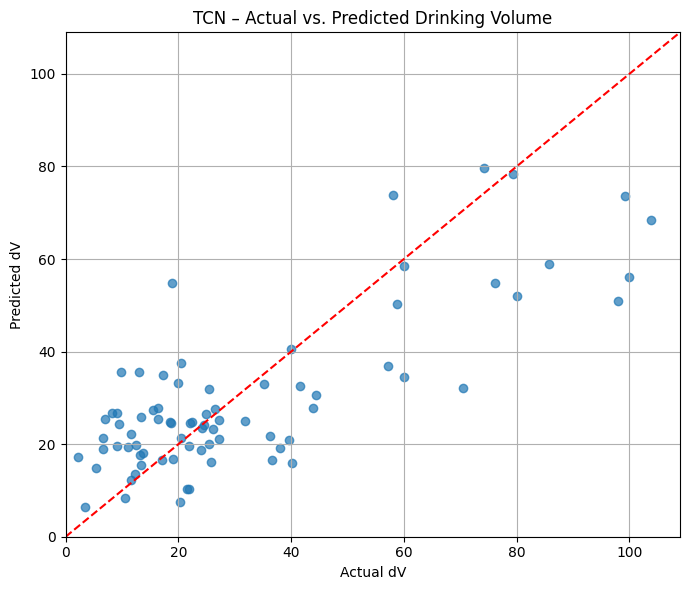

In [23]:
# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.tight_layout(); plt.show()

In [24]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [25]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 1.4691479 160.2
train_s min / max (log): -1.271691 4.6831155
